# Hot subdwarf stars

This notebook is used to prepare the GO proposal for hot subdwarf stars.

- Author: Nicholas Jannsen
- Last check: 2026-02-7
- PlatoSim version: `3.7.0-191-g42fc64d4`

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [87]:
# Built-in
import os
import sys
import glob

# Dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy import units as u
from pathlib import Path
from textwrap import dedent

# PlatoSim libraries
import platosim.plot      as pt
import platosim.utilities as ut
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:80% !important; }</style>"))

In [42]:
# Set global paths
hdir = Path(os.getenv('PLATO_PROJECT_HOME')) / 'inputfiles/data_picsim'
path = Path(os.getenv('PLATO_WORKDIR')) / 'go_hotsubdwarf'
idir = path / 'input'
fdir = path / 'figures'
sdir = path / 'simulations'

---
## 1. Stellar catalogue
---

### Inspect stellar catalogue

In [5]:
# Load hot subdwarf stars
df = pd.read_csv(idir / 'Plato_hot_subdwarf_stars.csv')
df

,name,source_id,ra,dec,phot_g_mean_mag,bp_rp,parallax,parallax_error,l,b
0,GaiaDR35572926710324060928,5572926710324060928,92.130599,-40.817173,14.491826,-0.330461,0.851083,0.023350,247.768369,-25.051994
1,GaiaDR35573125962446736384,5573125962446736384,93.218767,-39.381490,14.768272,-0.413017,0.722396,0.030862,246.499027,-23.860810
2,GaiaDR35577647154260869248,5577647154260869248,101.124488,-36.537021,16.856806,-0.249401,0.530204,0.050328,245.791846,-17.044635
3,2MASSJ04464929-6115101,4665681114618938112,71.705586,-61.252838,14.508868,0.044612,0.262058,0.019480,271.248539,-38.405526
4,TYC8076-1235-1,4789836284000445568,70.735411,-46.160875,12.275810,-0.075267,0.743688,0.022091,251.871680,-41.047829
...,...,...,...,...,...,...,...,...,...,...
329,GaiaDR34676030027297506432,4676030027297506432,64.071419,-63.759271,14.196742,-0.293299,1.162666,0.027023,275.779835,-40.957445
330,GaiaDR35278923726328106240,5278923726328106240,100.134015,-70.075787,14.791790,-0.239101,0.707269,0.025828,280.616600,-26.302604
331,EC04566-5006,4785371300422067072,74.482937,-50.029257,15.706899,0.330184,0.346800,0.029399,256.775821,-38.401905
332,GaiaDR35301148910779101568,5301148910779101568,128.935772,-61.460284,15.506160,0.405655,0.948991,0.101398,276.873956,-12.337390


<IPython.core.display.Javascript object>


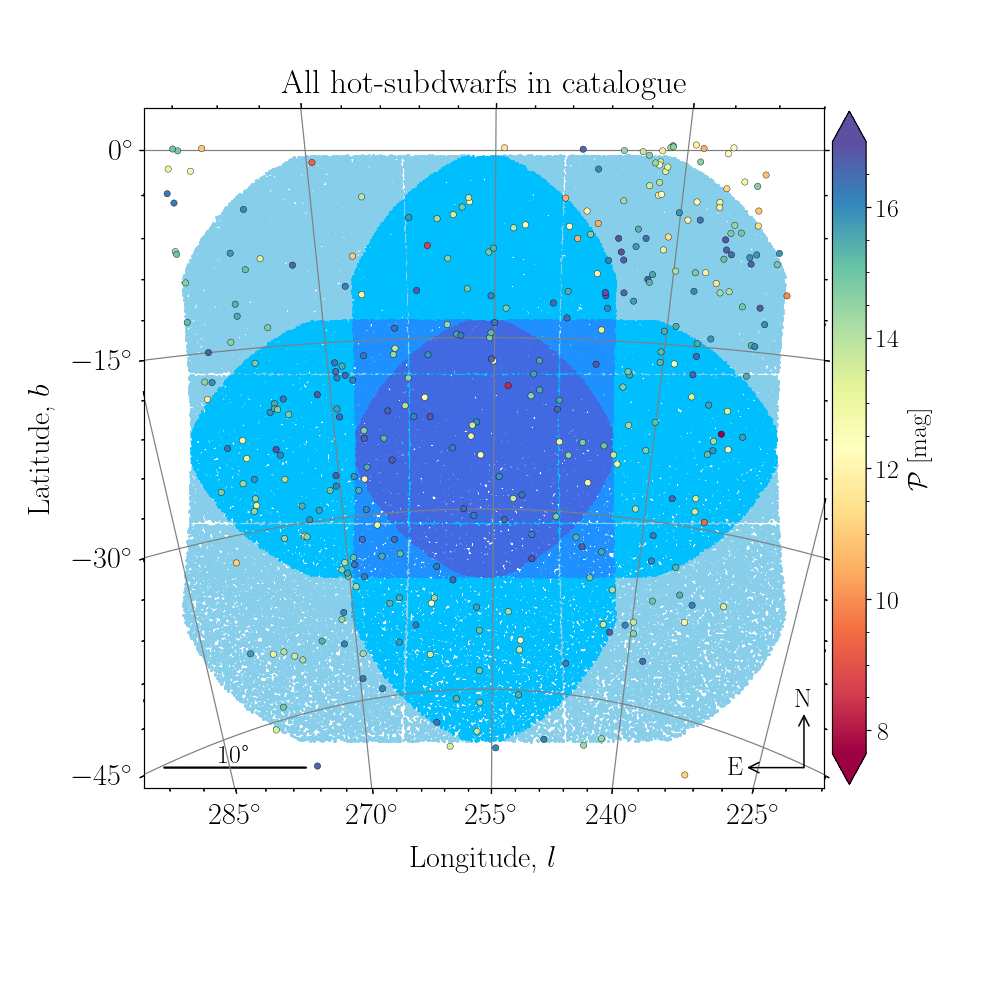

In [6]:
# Plot target in Galactic projection
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', fovSize=30, ncamStars=True,
    raStars=df.ra, decStars=df.dec, c=df.phot_g_mean_mag,
    clabel=r'$\mathcal{P}$ [mag]', s=70, lw=0.25,
    title='All hot-subdwarfs in catalogue', figsize=(9,9),
)
# fig.savefig(fdir / f'starcat_sky_targets_{filename}.png', bbox_inches='tight', dpi=200)

### Cross-match with LOPS2 N-CAM sources

In [22]:
# Load PLATO-CS catalogue
ds = pd.read_feather(hdir / 'PlatoCS_NCAM_LOPS2.ftr')
ds.gaiaDR3 = ds.gaiaDR3.astype('int64')
ds

,gaiaDR3,ra,dec,l,b,Pmag,PBmag,PRmag,Gmag,BP_RP,...,R_upp,M,M_low,M_upp,L,L_low,L_upp,spec,evol,ncam
0,4677205714465503104,69.189319,-62.077491,272.671893,-39.342582,1.448518,3.785840,0.560105,1.958775,3.770394,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,6
1,5300300156538723328,139.272369,-59.275176,278.459062,-7.011166,2.037026,2.179420,1.859075,2.213786,0.552959,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,6
2,5605797194566011520,111.023738,-29.303083,242.616496,-6.485724,2.335989,2.418159,2.227041,2.450408,0.339532,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,6
3,5610441600394646016,105.429755,-27.934809,239.168820,-10.273803,2.369039,3.053957,1.819715,2.760549,1.768627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,K,<NA>,6
4,5310393535853560576,140.528323,-55.010611,275.882156,-3.537435,2.402990,2.461229,2.323981,2.487886,0.246693,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28358166,5552052752651976448,98.708509,-47.968412,256.668424,-22.446870,19.122396,19.035864,19.253256,18.963625,-0.416525,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,24
28358167,5502633106599013504,97.339259,-51.308448,259.930923,-24.168748,19.132614,19.019403,19.305698,18.920208,-0.553066,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,24
28358168,5550978254914286080,97.182171,-50.181887,258.707380,-23.992113,19.142763,19.054300,19.276663,18.980139,-0.426327,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,24
28358169,5504630816145172480,105.088998,-51.963487,262.076591,-19.743369,19.168743,19.073547,19.313267,18.992630,-0.460617,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,24


In [23]:
# Cross-match with catalogues
dt = df[df['source_id'].isin(ds['gaiaDR3'])]
dt

,name,source_id,ra,dec,phot_g_mean_mag,bp_rp,parallax,parallax_error,l,b
0,GaiaDR35572926710324060928,5572926710324060928,92.130599,-40.817173,14.491826,-0.330461,0.851083,0.023350,247.768369,-25.051994
1,GaiaDR35573125962446736384,5573125962446736384,93.218767,-39.381490,14.768272,-0.413017,0.722396,0.030862,246.499027,-23.860810
2,GaiaDR35577647154260869248,5577647154260869248,101.124488,-36.537021,16.856806,-0.249401,0.530204,0.050328,245.791846,-17.044635
3,2MASSJ04464929-6115101,4665681114618938112,71.705586,-61.252838,14.508868,0.044612,0.262058,0.019480,271.248539,-38.405526
4,TYC8076-1235-1,4789836284000445568,70.735411,-46.160875,12.275810,-0.075267,0.743688,0.022091,251.871680,-41.047829
...,...,...,...,...,...,...,...,...,...,...
329,GaiaDR34676030027297506432,4676030027297506432,64.071419,-63.759271,14.196742,-0.293299,1.162666,0.027023,275.779835,-40.957445
330,GaiaDR35278923726328106240,5278923726328106240,100.134015,-70.075787,14.791790,-0.239101,0.707269,0.025828,280.616600,-26.302604
331,EC04566-5006,4785371300422067072,74.482937,-50.029257,15.706899,0.330184,0.346800,0.029399,256.775821,-38.401905
332,GaiaDR35301148910779101568,5301148910779101568,128.935772,-61.460284,15.506160,0.405655,0.948991,0.101398,276.873956,-12.337390


In [24]:
# Save catalogue
dt.reset_index(drop=True).to_csv(idir / 'Plato_hot_subdwarf_stars_ncams.csv')

<IPython.core.display.Javascript object>


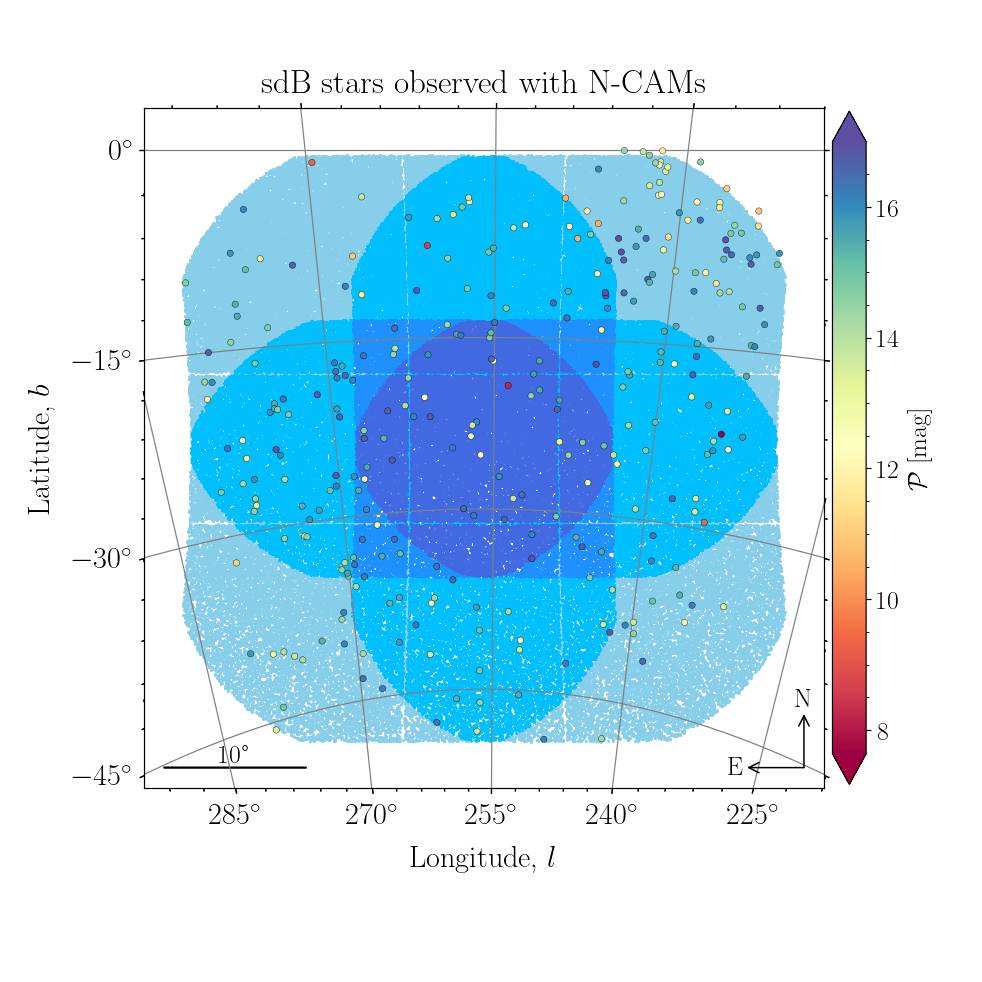

In [25]:
# Plot target in Galactic projection
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', fovSize=30, ncamStars=True,
    raStars=dt.ra, decStars=dt.dec, c=dt.phot_g_mean_mag,
    clabel=r'$\mathcal{P}$ [mag]', s=70, lw=0.25,
    title='sdB stars observed with N-CAMs', figsize=(9,9),
)
fig.savefig(fdir / f'starcat_sky_ncams.png', bbox_inches='tight', dpi=200)

Note that the reason why there are some targets outside the LOPS2 FOV is because the Valerie selected all cross-matches from Anna's target list below $r_{\rm OA} < 19.6$ deg.

### Cross-match with LOPS2 F-CAM sources

In [26]:
# Load PLATO-CS catalogue
ds = pd.read_feather(hdir / 'PlatoCS_FCAM_LOPS2.ftr')
ds.gaiaDR3 = ds.gaiaDR3.astype('int64')
ds

,gaiaDR3,ra,dec,Gmag,BP_RP,Ag,plx,plx_err,pmra,pmdec,...,S_err,spec,evol,variable,class,ncams,Pmag,Pgiant,PBmag,PRmag
0,5502164890740285696,102.484267,-50.614848,2.618499,1.312425,NaN,18.757713,0.347519,32.618184,-69.565734,...,NaN,G,<NA>,NOT_AVAILABLE,,6,2.282788,2.277100,2.718279,1.864839
1,2896572746685604480,95.078337,-30.063349,3.007651,0.069759,NaN,9.492206,0.447933,6.084451,4.247413,...,NaN,B,<NA>,NOT_AVAILABLE,,6,2.982762,2.982928,2.998538,2.960518
2,5478862906452936960,102.047058,-61.940116,3.203374,0.458191,NaN,NaN,NaN,NaN,NaN,...,NaN,A,<NA>,NOT_AVAILABLE,,6,3.053324,3.053446,3.168014,2.906023
3,5557271829408912896,99.440299,-43.195953,3.175233,0.098825,NaN,8.819389,0.288251,-0.537264,-3.858982,...,NaN,B,<NA>,NOT_AVAILABLE,,6,3.140169,3.140392,3.162667,3.108633
4,4757601523650165120,83.406311,-62.489769,3.593462,1.049574,0.3925,2.930785,0.139114,-0.611187,12.949733,...,NaN,F,<NA>,NOT_AVAILABLE,,6,3.302200,3.298827,3.620285,2.965348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595689,4756152710941311616,86.200359,-64.625596,16.997581,-0.231808,0.0134,0.062691,0.052648,1.624275,0.597684,...,NaN,B,<NA>,NOT_AVAILABLE,,6,17.084316,17.083603,17.034878,17.157562
1595690,4799881521014158976,80.493380,-45.189834,16.944908,-0.415487,0.0060,0.390238,0.048283,10.400172,0.405075,...,NaN,O,<NA>,NOT_AVAILABLE,,6,17.103271,17.102135,17.016943,17.233809
1595691,4806300199316094208,82.480514,-41.540082,16.956432,-0.461933,NaN,2.805125,0.051731,4.176935,-5.611352,...,NaN,O,<NA>,NOT_AVAILABLE,,6,17.133062,17.131897,17.037609,17.277994
1595692,4810897257431722368,76.098241,-43.974226,16.973370,-0.553024,NaN,2.175653,0.057416,6.909746,44.610506,...,NaN,O,<NA>,NOT_AVAILABLE,,6,17.185759,17.184683,17.072557,17.358831


In [27]:
# Cross-match with catalogues
dt = df[df['source_id'].isin(ds['gaiaDR3'])]
dt

,name,source_id,ra,dec,phot_g_mean_mag,bp_rp,parallax,parallax_error,l,b
0,GaiaDR35572926710324060928,5572926710324060928,92.130599,-40.817173,14.491826,-0.330461,0.851083,0.023350,247.768369,-25.051994
1,GaiaDR35573125962446736384,5573125962446736384,93.218767,-39.381490,14.768272,-0.413017,0.722396,0.030862,246.499027,-23.860810
2,GaiaDR35577647154260869248,5577647154260869248,101.124488,-36.537021,16.856806,-0.249401,0.530204,0.050328,245.791846,-17.044635
4,TYC8076-1235-1,4789836284000445568,70.735411,-46.160875,12.275810,-0.075267,0.743688,0.022091,251.871680,-41.047829
5,GaiaDR34792844272935841792,4792844272935841792,87.780025,-50.686608,16.618168,-0.355936,0.354133,0.046551,258.010160,-29.965904
...,...,...,...,...,...,...,...,...,...,...
322,GaiaDR35551984518508239744,5551984518508239744,98.597185,-48.369264,13.640960,-0.254899,1.185993,0.035015,257.063257,-22.629092
324,GaiaDR32883459794914510848,2883459794914510848,88.649860,-39.622882,13.003768,-0.201273,1.307256,0.021290,245.739950,-27.327127
325,GaiaDR35570524827173062656,5570524827173062656,98.531117,-40.425071,15.571545,-0.070526,0.590206,0.035904,248.902818,-20.292762
326,GaiaDR35572008721193797632,5572008721193797632,93.868357,-41.335344,13.202349,0.244212,1.572065,0.013363,248.702309,-23.928541


In [31]:
dt.sort_values(by='phot_g_mean_mag')

,name,source_id,ra,dec,phot_g_mean_mag,bp_rp,parallax,parallax_error,l,b
197,HD49798,5562023884304074240,102.019558,-44.316206,8.223742,-0.427691,1.919602,0.050080,253.706504,-19.140929
291,HD67269,5520413038558513280,121.296040,-45.406810,8.658205,-0.034237,3.092602,0.177568,260.750488,-7.302293
77,CPD-64481,4756263864690143616,86.997064,-64.384330,11.266701,-0.419136,4.395482,0.036552,273.879490,-31.086784
137,GaiaDR35482955799829681792,5482955799829681792,95.047940,-58.651380,11.842017,-0.501574,3.205848,0.042539,267.627268,-26.894454
7,TYC7641-1741-1,5558388241731286912,105.480220,-44.798202,12.167220,-0.342870,1.136625,0.034832,255.093947,-17.002606
...,...,...,...,...,...,...,...,...,...,...
198,GaiaDR35518269368835904000,5518269368835904000,117.449986,-48.149525,16.793760,0.182507,0.269355,0.047374,261.810090,-10.957218
139,GaiaDR35481509632801731840,5481509632801731840,96.846020,-60.916128,16.801401,-0.409422,0.418929,0.054716,270.285551,-26.347221
2,GaiaDR35577647154260869248,5577647154260869248,101.124488,-36.537021,16.856806,-0.249401,0.530204,0.050328,245.791846,-17.044635
55,GaiaDR35501837854749153024,5501837854749153024,101.431944,-51.680234,16.875198,-0.422529,0.398762,0.047215,261.046981,-21.807877


In [28]:
# Save catalogue
dt.reset_index(drop=True).to_csv(idir / 'Plato_hot_subdwarf_stars_fcams.csv')

<IPython.core.display.Javascript object>


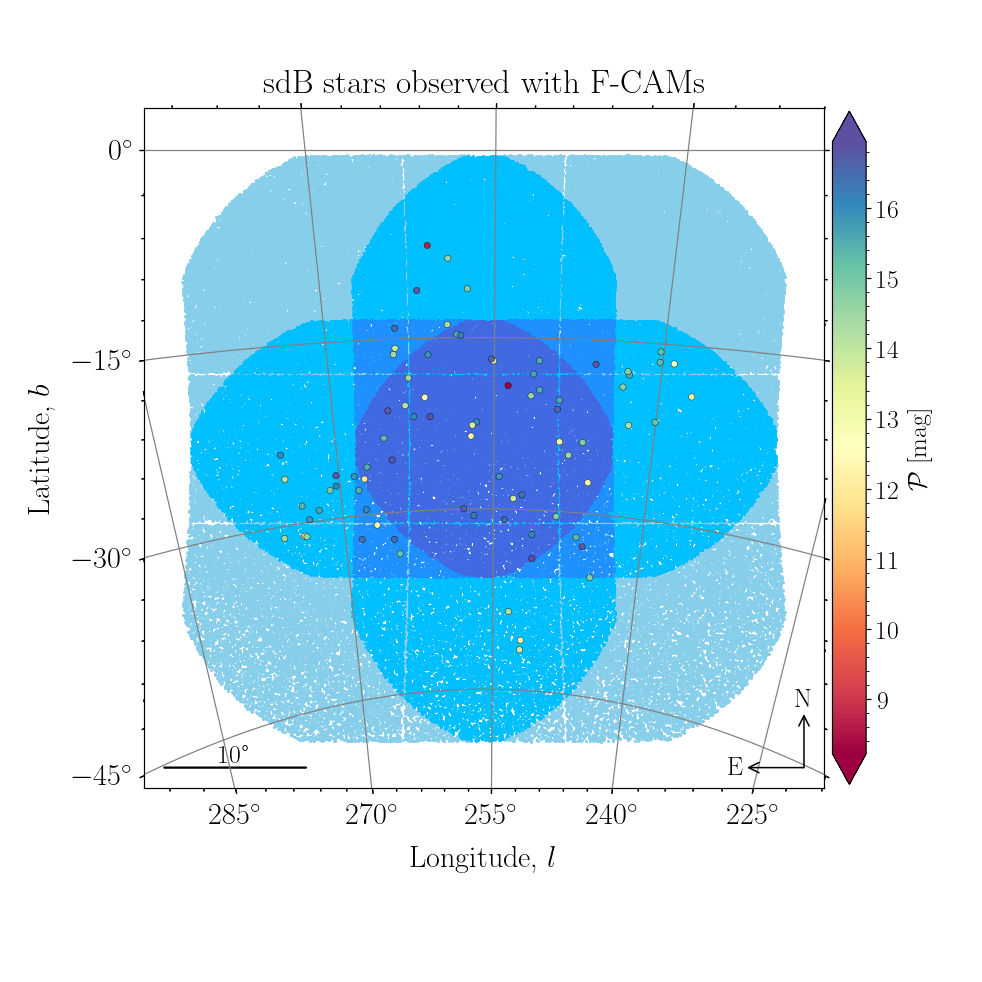

In [29]:
dt = dt
# Plot target in Galactic projection
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', fovSize=30, ncamStars=True,
    raStars=dt.ra, decStars=dt.dec, c=dt.phot_g_mean_mag,
    clabel=r'$\mathcal{P}$ [mag]', s=70, lw=0.25,
    title='sdB stars observed with F-CAMs ', figsize=(9,9),
)
# fig.savefig(fdir / f'starcat_sky_fcams.png', bbox_inches='tight', dpi=200)

In [31]:
# # Create target catalogue
# dt.reset_index(drop=True, inplace=True)
# dt.to_feather(idir / f'starcat_{filename}_targets.ftr')

In [1]:
# # Create contaminant catalogue
# dc = ut.getContaminants(dt, df, column='gaiaDR3')
# dc.to_feather(idir / f'starcat_{filename}_contaminants.ftr')

---
## 2. Hot subdwarf planet hosts
---

The targets selected were chosen to cover a representative mix of cases, including sdB/sdO stars, different brightness levels, different numbers of cameras, and both normal and fast cadence cases. The current sample is:
The targets selected were chosen to cover a representative mix of cases, including sdB/sdO stars, different brightness levels, different numbers of cameras, and both normal and fast cadence cases. The current sample is:

- HD49798
- HD67269
- HD41571
- HD78401
- EC05275-5809
- CD-31 4800 (Cheops target)  

For all cases, I adopted a 90-day baseline. The main cadence is 50 s, and I also generated 25 s versions for HD49798 and HD67269 as additional fast-cadence cases.

For the stellar parameters, I used simple representative values at this stage:

- sdO: Mstar = 0.47 Msun, Rstar = 0.25 Rsun
- sdB: Mstar = 0.47 Msun, Rstar = 0.15 Rsun

For the injected planetary scenarios, I explored:

- orbital periods of 1.0, 2.0, 3.0, and 5.0 days
- planetary radii of 0.5, 1.25, and 2.0 Earth radii

This gives:

 - 7 target/cadence configurations for the benchmark sample
 - each sampled over 4 periods and 3 planetary radii
 - for a total of 96 noiseless light curves

I also generated folded diagnostic plots for all of them as a sanity check, and everything looks consistent. The files available in the shared link below (`**`) already correspond to the final adopted stellar classification, including CD-31 4800 as an sdO.

All the information about coordinates, brightness can be consulted in the manifest.csv and in the hot_subdwarf_master_table.csv

### Show targets in sky

In [18]:
df_CD314800 = pd.read_feather(idir / 'starcat_CD-314800_targets.ftr')
df_EC05275  = pd.read_feather(idir / 'starcat_EC05275-5809_targets.ftr')
df_HD41571  = pd.read_feather(idir / 'starcat_HD41571_targets.ftr')
df_HD49798  = pd.read_feather(idir / 'starcat_HD49798_targets.ftr')
df_HD67269  = pd.read_feather(idir / 'starcat_HD67269_targets.ftr')
df_HD78401  = pd.read_feather(idir / 'starcat_HD78401_targets.ftr')
cat_CD314800 = SkyCoord(df_CD314800.ra, df_CD314800.dec, frame='icrs', unit=u.deg)
cat_EC05275  = SkyCoord(df_EC05275.ra, df_EC05275.dec, frame='icrs', unit=u.deg)
cat_HD41571  = SkyCoord(df_HD41571.ra, df_HD41571.dec, frame='icrs', unit=u.deg)
cat_HD49798  = SkyCoord(df_HD49798.ra, df_HD49798.dec, frame='icrs', unit=u.deg)
cat_HD67269  = SkyCoord(df_HD67269.ra, df_HD67269.dec, frame='icrs', unit=u.deg)
cat_HD78401  = SkyCoord(df_HD78401.ra, df_HD78401.dec, frame='icrs', unit=u.deg)

<IPython.core.display.Javascript object>


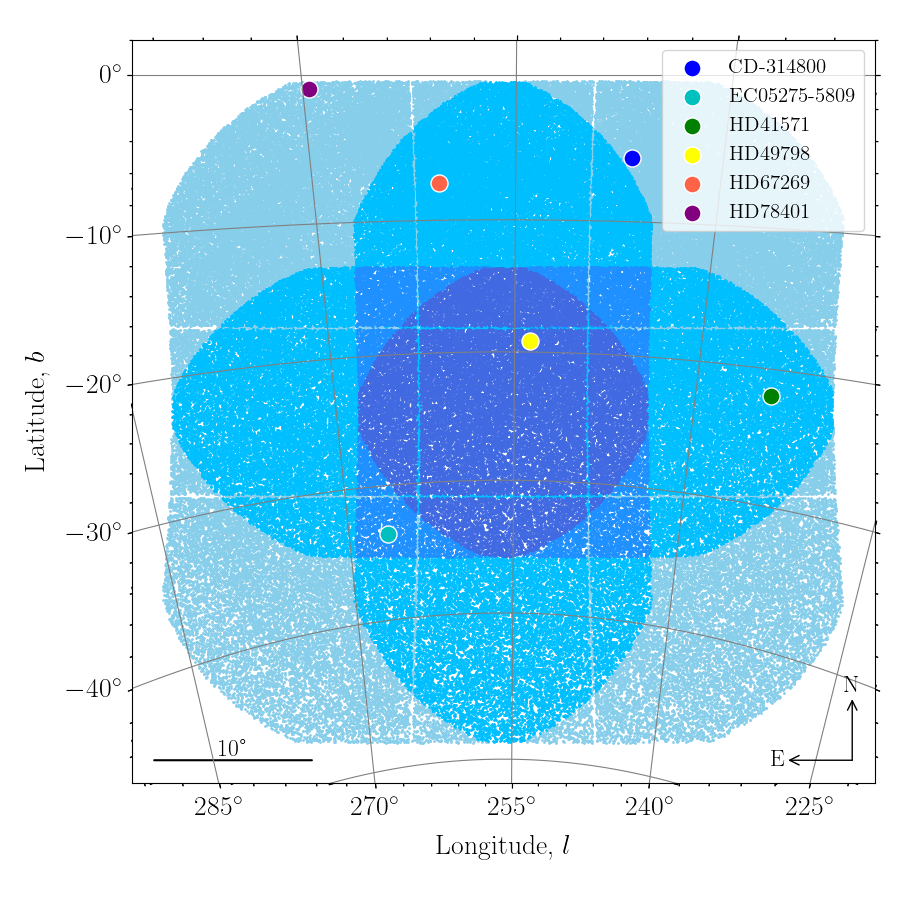

In [41]:
ms, ec = 150, 'w'
fig, ax = pt.plotPlatoFOV('LOPS2',ncamStars=True, clabel=r'$P$ [mag]', s=150, lw=0.3, figsize=(9,9))
ax.scatter(cat_CD314800.ra.deg, cat_CD314800.dec.deg, marker='o', c='blue', ec=ec, transform=ax.get_transform('icrs'), s=ms, label='CD-314800')
ax.scatter(cat_EC05275.ra.deg, cat_EC05275.dec.deg, marker='o', c='c', ec=ec, transform=ax.get_transform('icrs'), s=ms, label='EC05275-5809');
ax.scatter(cat_HD41571.ra.deg, cat_HD41571.dec.deg, marker='o', c='green', ec=ec, transform=ax.get_transform('icrs'), s=ms, label='HD41571');
ax.scatter(cat_HD49798.ra.deg, cat_HD49798.dec.deg, marker='o', c='yellow', ec=ec, transform=ax.get_transform('icrs'), s=ms, label='HD49798');
ax.scatter(cat_HD67269.ra.deg, cat_HD67269.dec.deg, marker='o', c='tomato', ec=ec, transform=ax.get_transform('icrs'), s=ms, label='HD67269');
ax.scatter(cat_HD78401.ra.deg, cat_HD78401.dec.deg, marker='o', c='purple', ec=ec, transform=ax.get_transform('icrs'), s=ms, label='HD78401');
ax.legend(loc='upper right')
fig.savefig(fdir / 'starcat_sky_targets.png', bbox_inches='tight', dpi=200)

### Light curves from Francisco J. Pozuelos

In [50]:
df = pd.read_csv(sdir / 'templates/lightcurves/CD_314800_50s_P5.0d_Rp2.00Re.txt', names=['time', 'flux'], sep=' ')

<IPython.core.display.Javascript object>


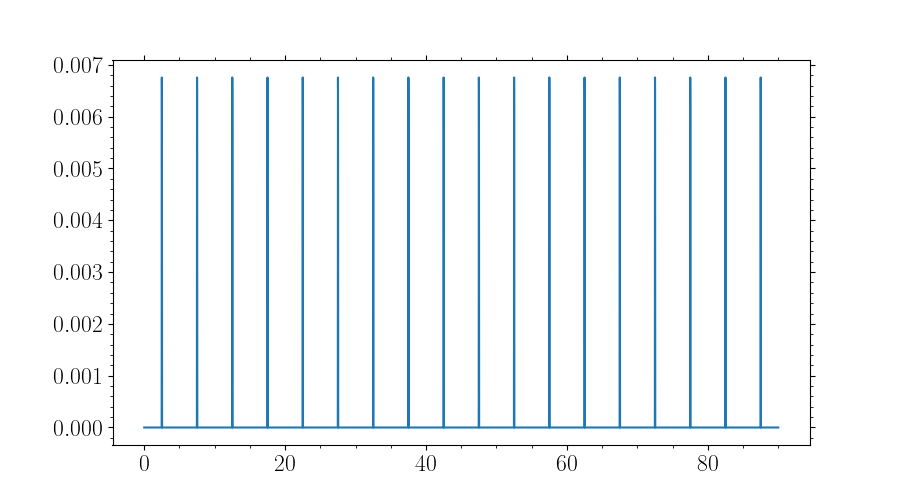

In [52]:
fig = plt.figure(figsize=(9,5))
plt.plot(df.time/86400, df.flux, '-');

### SLURM parameter file

In [129]:
files = glob.glob(f'{sdir}/templates/varsource/*')
filenames = sorted([Path(f).stem for f in files])
# filenames

In [133]:
textfile = "id,group,camera,quarter,name,stem\n"
for idNo,nameNo in zip(range(1, len(filenames)+1), filenames):
    for groupNo in range(1,5):
        for cameraNo in range(1,7):
            for quarterNo in range(1,2):
                name = Path(nameNo).stem.split('_')[0]
                textfile += f"{idNo},{groupNo},{cameraNo},{quarterNo},{name},{nameNo}\n"
# Save file to input directory
with open(sdir / 'slurm/cluster_sims.data', "w") as ofile:
    ofile.write(dedent(textfile).strip())

In [132]:
# print(textfile)